---

## **Prerequisites / Setup**

$\Rightarrow$ Special setup instructions, imports and configurations go here.


# **Project work: A mini segmentation challenge**
## Segmentation of diseased leaves
<div style="color:#777777;margin-top: -15px;">
<b>Course</b>: MSLS / CO4 |
<b>Version</b>: v1.3 <br><br>
<!-- 10.04.2025, v1.2: Fully refactored -->
<!-- 17.04.2026, v1.3: Introduced word count limits -->
</div>


**Student**: $\Rightarrow$ Rebecca Siebeneicher, Maria Morales
**Email**: $\Rightarrow$ siebere2@students.zhaw.ch, moralma1@students.zhaw.ch
**University**: $\Rightarrow$  ZHAW
**Semester**: $\Rightarrow$  FS 2026 
**Date**: $\Rightarrow$  31.05.2026


<br>

## **Abstract**
This project focuses on the segmentation of apple leaves and dark spots caused by apple scab disease using both manual and automated approaches. The leaf segmentation achieved excellent results with a mean Dice score of 0.99, while the dark spot segmentation performed poorly due to the large overlap in HSV values between diseased and healthy tissue. These findings suggest that more advanced methods, such as machine learning, would be necessary to achieve reliable dark spot detection.



<br><br>

----

## **Table of contents**
<!-- Unfortunately, the following does not always work correctly -->
* [1. Dataset](#sec_dataset)  
* [2. Preprocessing](#sec_preprocessing)  
* [3. Manual segmentation](#sec_manual_segmentation)  
* [4. Automated segmentation](#sec_automated_segmentation)  
* [5. Evaluation](#sec_evaluation)  
* [6. Discussion](#sec_discussion)  
* [Appendix: Hints](#sec_hints)  


In [10]:
import numpy as np
import os
import matplotlib.pyplot as plt
import cv2 as cv
import PIL
import pandas as pd

# Jupyter / IPython configuration:
# Automatically reload modules when modified
%load_ext autoreload
%autoreload 2

# Enable vectorized output (for nicer plots)
%config InlineBackend.figure_formats = ["svg"]

# Inline backend configuration
%matplotlib inline

# Enable this line if you want to use the interactive widgets
# It requires the ipympl package to be installed.
#%matplotlib widget

import sys
sys.path.insert(0, "../")
import tools

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---


<a id='sec_dataset'></a>

## **Dataset**
Apple scab is one of the most common diseases in apples all around the world, caused by a fungus. It results in the highest apple loss caused by a disease. Although infected trees cannot be cured, the disease can be controlled, and its spread to neighbouring trees can be effectively prevented. For this reason, considerable effort is invested in prevention. However, early detection remains essential once the disease has occurred. Typical symptoms include dark lesions on both leaves and fruit (Vaillancourt & Hartman, 2000).

The aim of this project is therefore to segment the diseased regions on apple leaves affected by apple scab.

The original dataset was provided by Pandian and Gopal (2019) and consists of 1000 images of apple leaves showing symptoms of apple scab. According to the usage license, the dataset can be freely copied, modified, distributed, and used without requiring permission. For this project, the dataset was filtered to include only images taken in the shadow, showing flat leaves, and ensuring that each image represents a different leaf. After this selection process, 10 images remained.
The images were acquired using standard RGB digital photography. The structures of interest are the leaf itself and the dark spots caused by the apple scab fungus.


In [11]:
# Import the 11 selected images of leaves with apple scab
images = [cv.imread(os.path.join("data/leaves", f))
          for f in sorted(os.listdir("data/leaves")) if f.endswith(".JPG")]

---

<a id='sec_preprocessing'></a>

## **Preprocessing**
As shown in the code block below, all 10 selected images have identical dimensions and formats. Therefore, no standardization was necessary. Since the contrast between the background and the leaf is sufficiently strong in all images, no additional preprocessing was needed before creating the masks of the leaves.
For the dark spot segmentation, several preprocessing techniques were tested on the original images in an attempt to enhance the contrast between the dark spots and the healthy leaf tissue:
-	Green Channel Extraction: the green channel was isolated as it shows the strongest contrast between healthy and diseased regions
-	Black Top Hat: applied to enhance dark structures on a bright background
-	Closing: used to fill small gaps within detected regions
-	Smoothing: applied to reduce noise

However, none of these approaches improved the quality of the dark spot masks significantly. Therefore, no preprocessing was applied to the original images. Instead, closing and opening were applied to the segmentation mask after thresholding as part of the automated segmentation pipeline. Visual examples are provided in the chapter Automated Segmentation. Closing was applied first to fill small gaps within detected regions, followed by opening to remove small noise artefacts.





In [12]:
# Checking the image dimensions and formats of the original images
for img in images:
    print(img.shape, img.dtype)

(256, 256, 3) uint8
(256, 256, 3) uint8
(256, 256, 3) uint8
(256, 256, 3) uint8
(256, 256, 3) uint8
(256, 256, 3) uint8
(256, 256, 3) uint8
(256, 256, 3) uint8
(256, 256, 3) uint8
(256, 256, 3) uint8


---

<a id='sec_manual_segmentation'></a>

## **Manual segmentation**
As described in the chapter Dataset, 10 images of leaves with dark spots coming from an apple scab disease were selected. For each image two masks were manually created using Fiji. The first mask separates the background and the leaf. The second mask separates the dark spots and the leaf. This was done in two different steps, to ensure, that the background will not be counted as a dark spot, since the background and the dark spots are quite similar in colour. 

Fiji was chosen for the manual segmentation in this project because it is a widely used, free, and open-source software for scientific image analysis (Schindelin et al., 2012). Originally developed for applications in cell biology and microscopy, it offers a broad range of plugins that make it well suited for segmenting images with clear structural features and colour contrasts (Arganda-Carreras et al., 2017), as it is the case for the dataset used for this project.

#### **Description Segmentation leaf and background:**
As mentioned in the chapter preprocessing, for the segmentation of the leaves and the background no preprocessing was necessary, since the contrast between the green leaf and the dark background was strong enough to directly use colour thresholding. The exact thresholding parameters used for each image are provided in the appendix. 
Due to the similarity in colour between the dark spots and the background, the initial thresholding often resulted in small holes within the leaf region. These were corrected using the “Fill Holes” function. In some cases, additional manual adjustments were necessary, particularly when dark spots were located at the leaf edges, when shadows affected the leaf boundary, or when the leaf had physical damage such as tears.
Around the edges, the manual correction was challenging due to the serrated edges of the leaves.  

The creation of each mask required approximately 2–3 minutes. The final masks separating leaf and background are provided at the end of this chapter.

#### **Description Segmentation leaf and dark spots:**
As described in the chapter preprocessing in more detail, different settings to enhance the contrast between the dark spots and the leaf were tested. After that colour thresholding or thresholding was applied. Some of the resulting masks were better than others, but in general the results were poor and therefore not usable as the ground truth masks. Consequently, the segmentation of the dark spots was performed manually using the Region of Interest (ROI) Manager. Each dark spot was individually outlined and stored, and a final mask was generated from these regions.

The process of segmenting the dark spots by hand presented several challenges. Upon closer inspection, the dark spots were found to consist not only of dark pixels but also of varying shades of green, making it difficult to clearly distinguish between diseased and healthy regions. This ambiguity also explains why the thresholding methods did not work properly. Additionally, this manual approach is not scalable to larger datasets, as it required approximately 2–6 minutes per image, depending on the number and complexity of the dark spots present.

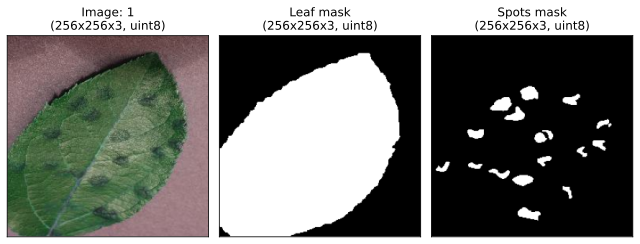

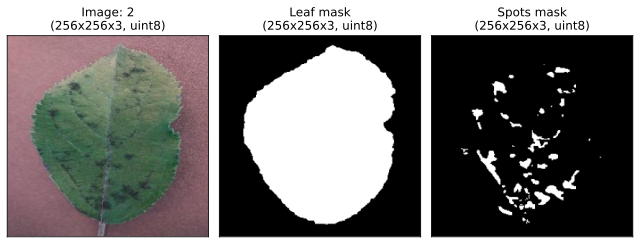

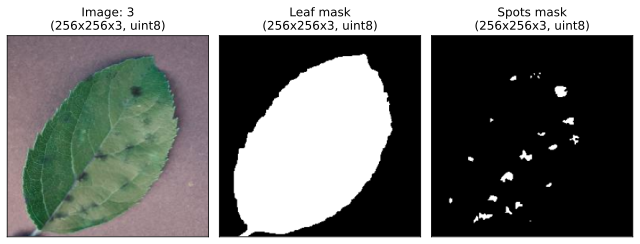

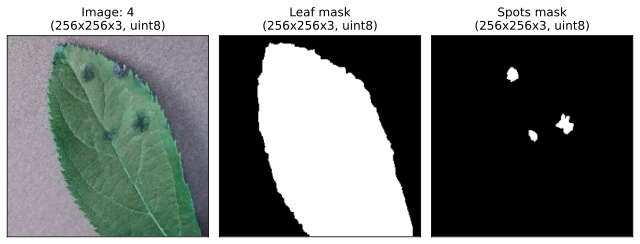

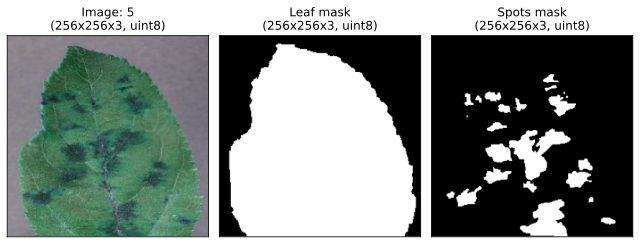

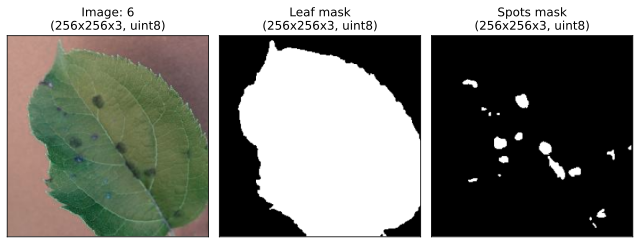

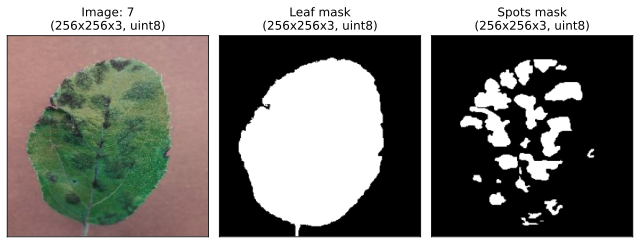

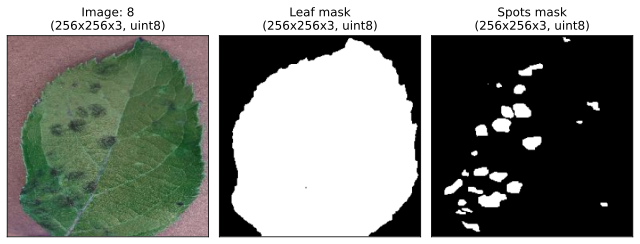

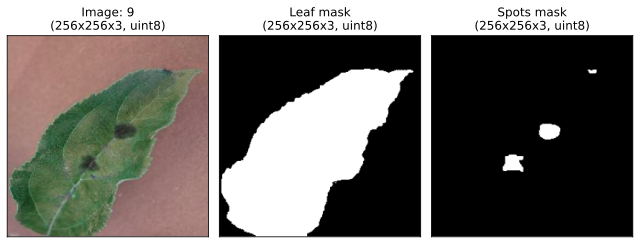

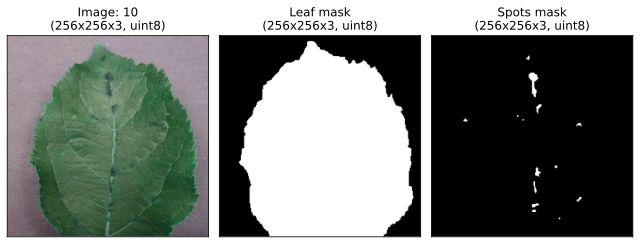

In [13]:
# Import the 11 manually created masks of the leaves
manual_masks_leaves = [cv.imread(os.path.join("data/manual-leaves", m))
          for m in sorted(os.listdir("data/manual-leaves")) if m.endswith(".png")]


# Imort the 11 manually created masks of the dark spots on the leaves
manual_masks_dark_spots = [cv.imread(os.path.join("data/manual-spots", m))
          for m in sorted(os.listdir("data/manual-spots")) if m.endswith(".png")]

count = 1
for (img, manual_leaf, manual_spots) in zip(images, manual_masks_leaves, manual_masks_dark_spots):
    tools.show_image_chain([img,manual_leaf,manual_spots],
                           titles=["Image: " + str(count), "Leaf mask", "Spots mask"])
    count = count + 1

---

<a id='sec_automated_segmentation'></a>

## **Automated Segmentation**

To generate the leaf masks of the 10 images in the dataset the threshold method was used. After analyzing the images it was decided that HSV format would be the best way to separate the leave from the background since color is what characterize the leaf from the floor. The channel H (Hue) was analyzed from image 1 to display the distribution of the H values. As shown on the hue distribution histogram, there are distinct groups that show different ranges of values. To determine which range belongs to the leaf a single known pixel of it was sampled. With this range the threshold was applied and tried on the 10 images, in order for it to work, the channel S (saturation) and V (value) were not taken into account and therefore set to the whole possible range (0 - 255). To complete the holes created by the pixels that didn't fell into the range the morphological operation close was used. This generated the 10 leaf masks without any major difference to the manual masks. As seen on image 2 and 4 the shadows and dark spots on the edges cause potential discrepancies as these pixels are not considered holes so the morphological operation is not able to close them. 

To determine the channel that would be more effective to focus on for the dark spots mask, the formats RGB and HSV were considered. The channels RGB showed big overlap between leaf and spots so no effective range was determined. However, after analyzing the HSV format it was decided to work with the S and V channels. A function sample_spots was created in order to explore different pixels of images. Pictures of isolated healthy and sick tissue were generated and the values of the channel HSV were saved. After exploring the samples of the 10 images the minimun and maximum value of the S and V channel on healthy and sick tissue were showed. With this guide different values were tried on the threshold. Because of the overleap between the channels it was challenging to find an intermediate between losing spots of interest and not showing healthy tissue on the mask. After the threshold was found and applied on the images two morphological operations were used to improve the results. First close was applied to fill the spots that got through the threshold. A lot of noise was generated because of the pixels on healthy tissue that were darker because of shadows or other factors. To reduce that the morphological operation open was applied. This made the dark spots visible and with clean edges. On images were the spots were too small or too similar to healthy tissue the results were not accurate. This can be seen on images 5 and 10. But good results were achive in order to make a count of the dark spots, like images 6, 8 and 9. 

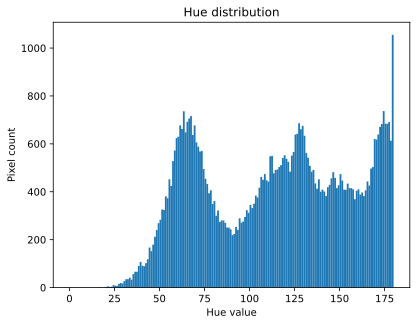

Dark S range: 17 - 108
Dark V range: 43 - 125
Healthy S range: 51 - 134
Healthy V range: 86 - 149


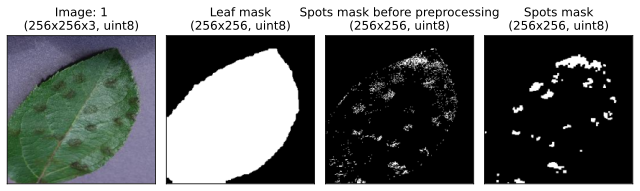

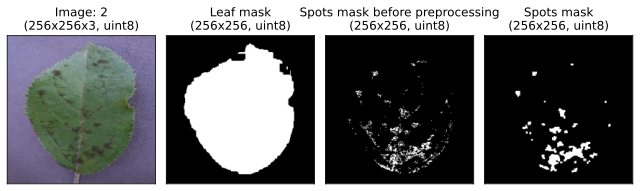

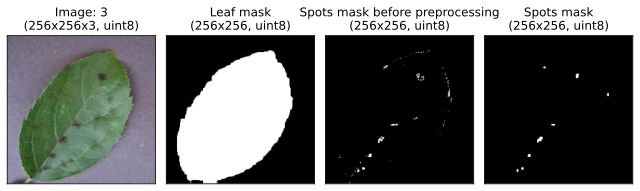

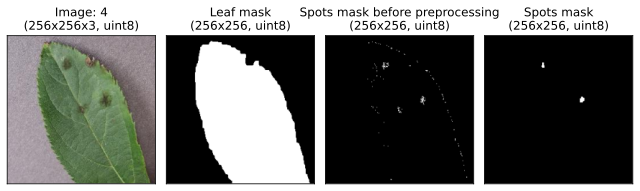

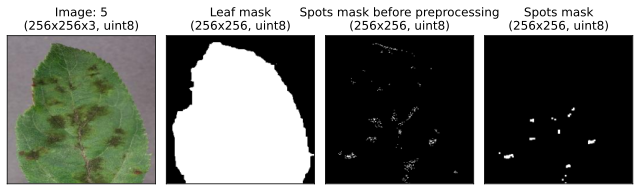

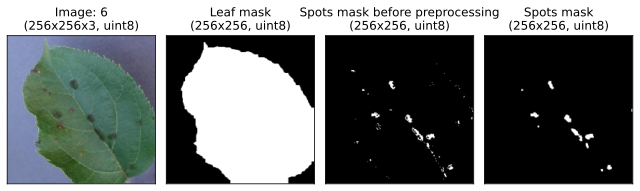

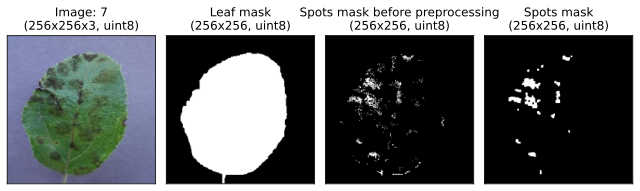

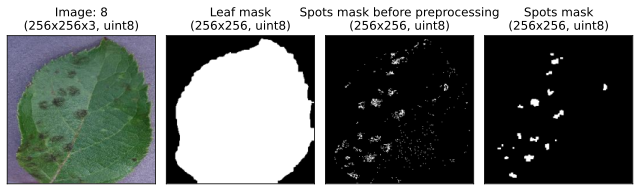

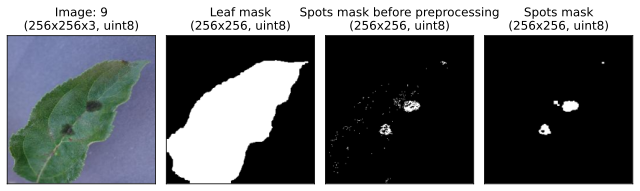

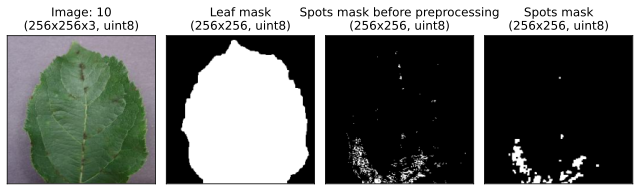

In [14]:
#Import the samples of dark spots and healthy tissue of each picture in the dataset
dark_spots = [cv.imread(os.path.join("data/dark-spots", f))
          for f in sorted(os.listdir("data/dark-spots")) if f.endswith(".JPG")]
healthy_tissue = [cv.imread(os.path.join("data/healthy-spots", f))
          for f in sorted(os.listdir("data/healthy-spots")) if f.endswith(".JPG")]
#Import first image to use as reference for the color of the leaves
base_img = cv.imread("data/leaves/image_19.JPG")
base_img_hsv = cv.cvtColor(base_img, cv.COLOR_BGR2HSV)
# Plot the hue histogram and determine the range of the leave
plt.hist(base_img[:,:,0].flatten(), bins=180, range=[0,180])
plt.xlabel("Hue value")
plt.ylabel("Pixel count")
plt.title("Hue distribution")
plt.show()

#Function to sample pixels in images of dark spots and healthy tissue to get the range for the threshold
def sample_spots(dark, healthy):
    dark_hsv = cv.cvtColor(dark, cv.COLOR_BGR2HSV)
    healthy_hsv = cv.cvtColor(healthy, cv.COLOR_BGR2HSV)
    dark_values = [dark_hsv[4,4],dark_hsv[8,4],dark_hsv[8,4],dark_hsv[8,8]]
    healthy_values = [healthy_hsv[10,10],healthy_hsv[20,10],healthy_hsv[10,20],healthy_hsv[20,20]]
    dark_s = [v[1] for v in dark_values]
    dark_v = [v[2] for v in dark_values]
    healthy_s = [v[1] for v in healthy_values]
    healthy_v = [v[2] for v in healthy_values]
    return dark_s, dark_v, healthy_s, healthy_v

dark_svalues = []
dark_vvalues = []
healthy_svalues = []
healthy_vvalues = []

#Sample each picture to determine the range of the spots of interest
for (dark, healthy) in zip(dark_spots, healthy_tissue):
    dark_s, dark_v, healthy_s, healthy_v = sample_spots(dark, healthy)
    dark_svalues.extend(dark_s)
    dark_vvalues.extend(dark_v)
    healthy_svalues.extend(healthy_s)
    healthy_vvalues.extend(healthy_v)

#Show the minimum and maximum value of each channel 
print(f"Dark S range: {min(dark_svalues)} - {max(dark_svalues)}")
print(f"Dark V range: {min(dark_vvalues)} - {max(dark_vvalues)}")
print(f"Healthy S range: {min(healthy_svalues)} - {max(healthy_svalues)}")
print(f"Healthy V range: {min(healthy_vvalues)} - {max(healthy_vvalues)}")

def segment(img,count):
    img_hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    #Threshold according to the hue distribution to eliminate background
    green_lower = np.array([30,  0, 0])
    green_upper = np.array([85, 255, 255])
    leaf_holes_mask = cv.inRange(img_hsv, green_lower, green_upper)

    #Morphological operation CLOSE to complete the structure of the leaf 
    size = (9, 9)
    se = cv.getStructuringElement(cv.MORPH_RECT, size)
    leaf_mask = cv.morphologyEx(leaf_holes_mask, cv.MORPH_CLOSE, se, iterations=1)

    #Save the leaf without background to create the spots mask
    leaf = img_rgb.copy()
    leaf[leaf_mask == 0] = [0, 0, 0]

    #Threshold with the best range for the dataset in channels S and V 
    spots_lower = np.array([0,  17, 43])
    spots_upper = np.array([255, 80, 125])
    spots_mask = cv.inRange(leaf, spots_lower, spots_upper)
    
    #Morphological operation CLOSE and then OPEN to complete the spots of interest and then reduce noise 
    size = (3, 3)
    se = cv.getStructuringElement(cv.MORPH_RECT, size)
    spots_mask_close = cv.morphologyEx(spots_mask, cv.MORPH_CLOSE, se, iterations=1)
    spots_mask_open = cv.morphologyEx(spots_mask_close, cv.MORPH_OPEN, se, iterations=1)
    final_mask = cv.bitwise_and(leaf_mask, spots_mask_open)

    
    tools.show_image_chain([img_rgb, leaf_mask,spots_mask, final_mask],
                       titles=["Image: " + str(count),  "Leaf mask", "Spots mask before preprocessing", "Spots mask"])
    
    return leaf_mask, final_mask

    

automated_leaf_masks = []
automated_spots_masks = []
count = 1
for img in images:
    auto_leaf, auto_spots = segment(img,count)
    count = count + 1
    automated_leaf_masks.append(auto_leaf)
    automated_spots_masks.append(auto_spots)

---

<a id='sec_evaluation'></a>

## **Evaluation**
The Dice coefficient and the Intersection over Union (IoU) were used as evaluation metrics to compare the automated segmentation masks with the manual ground truth masks. The Dice coefficient measures the overlap between two masks as twice the intersection divided by the sum of both masks:
$$D(X, Y) = \frac{2|X \cap Y|}{|X| + |Y|}$$
The IoU measures the intersection divided by the union of the two masks:
$$IoU(X, Y) = \frac{|X \cap Y|}{|X \cup Y|}$$

Both metrics range from 0 (no overlap) to 1 (perfect overlap).

The evaluation of the leaf masks shows a good overall agreement between the manual and automated segmentation results, with a mean Dice score of 0.99 (std: 0.0079) and a mean IoU of 0.98 (std: 0.0153). The automated method performed particularly well on images where no dark spots were present near the leaf edges. In cases where shadows or dark spots were located at the boundary of the leaf, these regions were occasionally misclassified as background, which reduced the scores for those images.

The evaluation of the dark spot masks shows a poor agreement between the manual and automated segmentation results, with a mean Dice score of 0.37 (std: 0.2178) and a mean IoU of 0.24 (std: 0.1776). This outcome was expected, given the large overlap in the S and V channel values between the dark spots and the healthy leaf tissue, which makes a reliable pixel-level separation inherently difficult for intensity-based methods.



In [15]:
# Convert to gray scale to have the same shape as the other masks 
gray_manual_leaf_mask = []
for manual_mask in manual_masks_leaves:
    manual_gray = cv.cvtColor(manual_mask, cv.COLOR_BGR2GRAY)
    gray_manual_leaf_mask.append(manual_gray)

# Metric functions dice and iou (the code provided during the lecture was used to implement these functions)
def dice(mask1, mask2):
    """Compute the Dice coefficient. The input masks should be binary."""
    assert mask1.shape == mask2.shape
    assert mask1.dtype == bool and mask2.dtype == bool
    intersection = mask1 & mask2  
    return 2*np.sum(intersection)/(np.sum(mask1) + np.sum(mask2))   


def iou(mask1, mask2):
    """Compute the Intersection over Union coefficient. The input masks should be binary."""
    assert mask1.shape == mask2.shape
    assert mask1.dtype == bool and mask2.dtype == bool
    intersection = mask1 & mask2
    union = mask1 | mask2
    return np.sum(intersection)/np.sum(union)


# Evaluation function -> here the manually created and the automated masks are compared individually using the dice and iou functions 
def evaluate(auto_mask, manual_mask):
    """If necessary, converts the masks to grayscale and compares the automated mask with the manual mask and returns the Dice and IoU scores."""
    if auto_mask.ndim == 3:
        auto_mask = cv.cvtColor(auto_mask, cv.COLOR_BGR2GRAY)
    if manual_mask.ndim == 3:
        manual_mask = cv.cvtColor(manual_mask, cv.COLOR_BGR2GRAY)
    return {"Dice": dice(auto_mask > 0, manual_mask > 0), 
            "IoU":  iou(auto_mask > 0, manual_mask > 0)}

# Calculate the evaluation scores and storing them in a list
scores_leaves = [evaluate(auto, manual)
                 for auto, manual in zip(automated_leaf_masks, gray_manual_leaf_mask)]

scores_spots = [evaluate(auto, manual)
                for auto, manual in zip(automated_spots_masks, manual_masks_dark_spots)]

# Calculate the mean and the standard deviation across all leaf masks and all dark spots masks
df_leaves = pd.DataFrame(scores_leaves)
df_spots = pd.DataFrame(scores_spots)

# Display the scores for each image and the mean and standard deviation across all images for both leaf masks and dark spot masks
print("=== Leaf masks: per-image scores ===")
display(df_leaves.round(4))

print("=== Leaf masks: mean ± std ===")
display(df_leaves.agg(["mean", "std"]).round(4))

print("\n=== Dark spot masks: per-image scores ===")
display(df_spots.round(4))

print("\n=== Dark spot masks: mean ± std ===")
display(df_spots.agg(["mean", "std"]).round(4))

=== Leaf masks: per-image scores ===


,Dice,IoU
0,0.9988,0.9976
1,0.9718,0.9451
2,0.9899,0.9801
3,0.9851,0.9706
4,0.9897,0.9796
5,0.9867,0.9738
6,0.9928,0.9856
7,0.9980,0.9961
8,0.9922,0.9845
9,0.9962,0.9925


=== Leaf masks: mean ± std ===


,Dice,IoU
mean,0.9901,0.9806
std,0.0079,0.0153



=== Dark spot masks: per-image scores ===


,Dice,IoU
0,0.4476,0.2883
1,0.5198,0.3512
2,0.2887,0.1687
3,0.2663,0.1536
4,0.0949,0.0498
5,0.5224,0.3536
6,0.2751,0.1595
7,0.4213,0.2669
8,0.7736,0.6308
9,0.0417,0.0213



=== Dark spot masks: mean ± std ===


,Dice,IoU
mean,0.3651,0.2444
std,0.2178,0.1776


---

<a id='sec_discussion'></a>

## **Discussion**

The results show a clear difference in segmentation performance between the two structures of interest (leaves and dark spots). The leaf segmentation achieved good results due to the strong colour contrast between the green leaf and the dark background. The main challenges occurred at the leaf edges, where shadows or dark spots were occasionally misclassified as background. 
The dark spot segmentation performed poorly across the entire dataset. An inspection of the HSV values revealed a large overlap in the S and V channel values between the dark spots and the healthy leaf tissue, making a reliable separation difficult for intensity-based methods. This also explains why none of the tested preprocessing techniques improved the results significantly.

For future work, machine learning methods such as convolutional neural networks could potentially overcome these limitations, as they are capable of learning more complex features beyond simple pixel intensity.




---

<a id='sec_references'></a>

## **References**
Arganda-Carreras, I., Kaynig, V., Rueden, C., Eliceiri, K. W., Schindelin, J., Cardona, A., & Sebastian Seung, H. (2017). Trainable Weka Segmentation: a machine learning tool for microscopy pixel classification. Bioinformatics, 33(15), 2424–2426. https://doi.org/10.1093/bioinformatics/btx180

Schindelin, J., Arganda-Carreras, I., Frise, E., Kaynig, V., Longair, M., Pietzsch, T., Preibisch, S., Rueden, C., Saalfeld, S., Schmid, B., Tinevez, J.-Y., White, D. J., Hartenstein, V., Eliceiri, K., Tomancak, P., & Cardona, A. (2012). Fiji: an open-source platform for biological-image analysis. Nature Methods, 9(7), 676–682. https://doi.org/10.1038/nmeth.2019

Vaillancourt, L. J., & Hartman, J. R. (2000). Apple scab. The Plant Health Instructor. American Phytopathological Society. https://www.apsnet.org/edcenter/pdlessons/Pages/AppleScab.aspx

The code provided during the CO4 lecture was used in parts of this project 


## **Decleration on the usage of AI**

In the process of creating this project, generative AI tools (Claude) were used as supportive instruments. They were used to help with the following tasks: assisting with language refinement, structuring of text, improving clarity and readability, helping to understand the provided code from the lectures, finding new ideas to improve contrast for the creation of the dark spot masks. 

All core elements of the project, including finding and filtering the dataset, creating the manual and automated masks of the leaves and the dark spots and creating the evaluation functions were developed independently by the authors. The final content reflects the authors’ own understanding and work.




<br><br><br><br><br><br><br><br>

---
<a id='sec_appendix'></a>

## **Appendix**
#### **Settings manual leaves masks**
In the following code block, the settings used to generate the leaf masks using thresholding are provided.

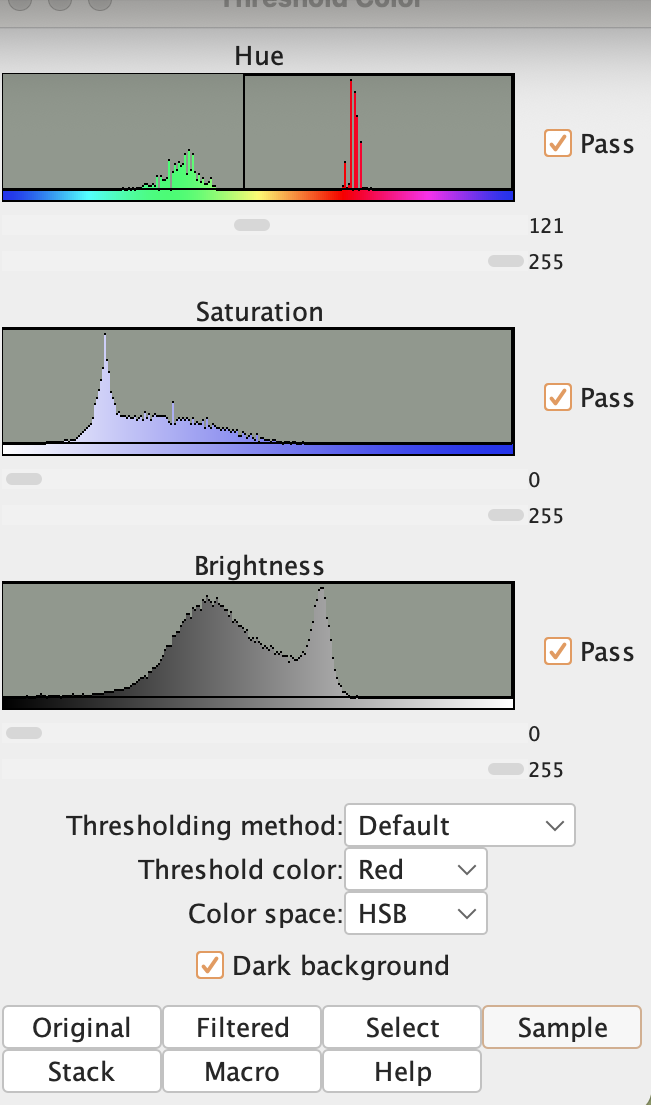

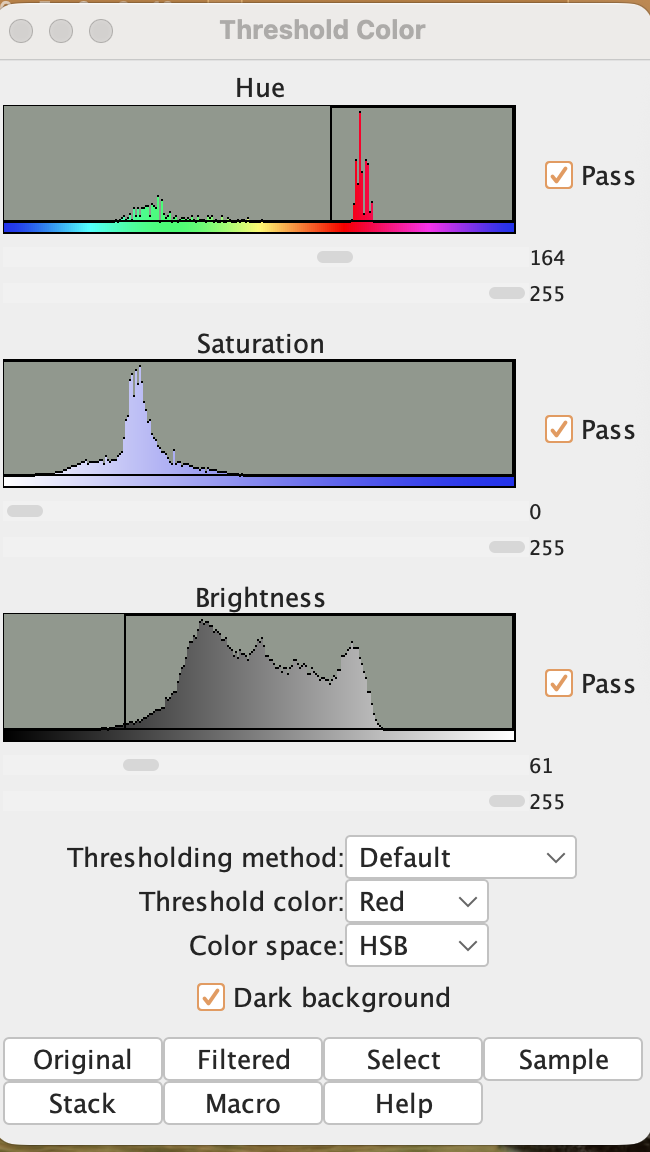

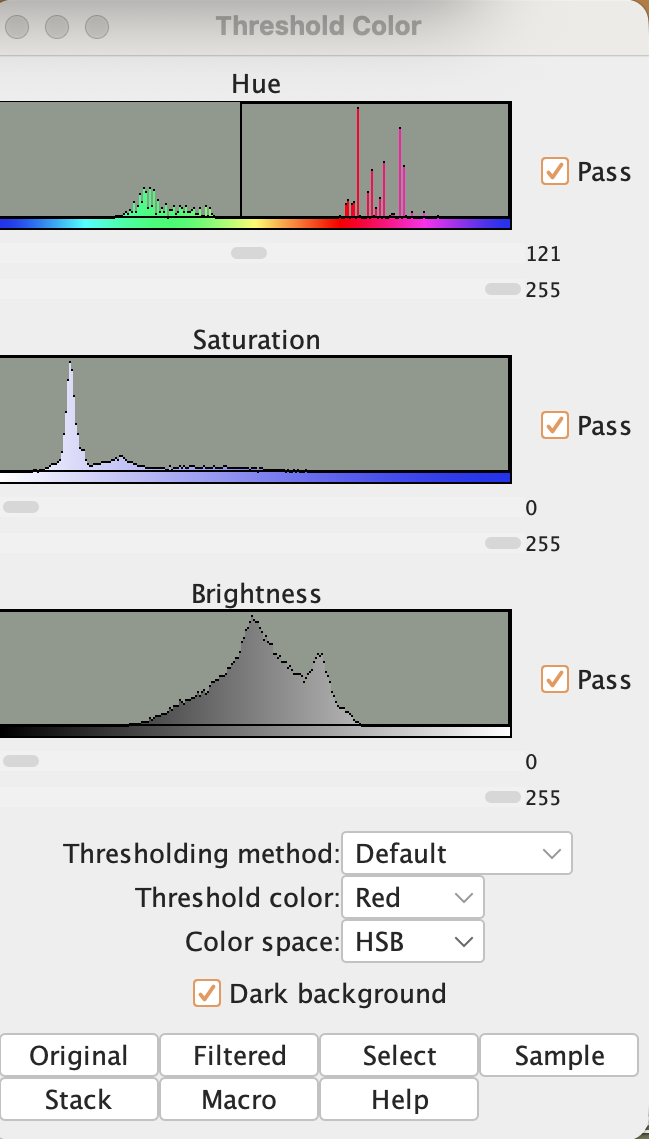

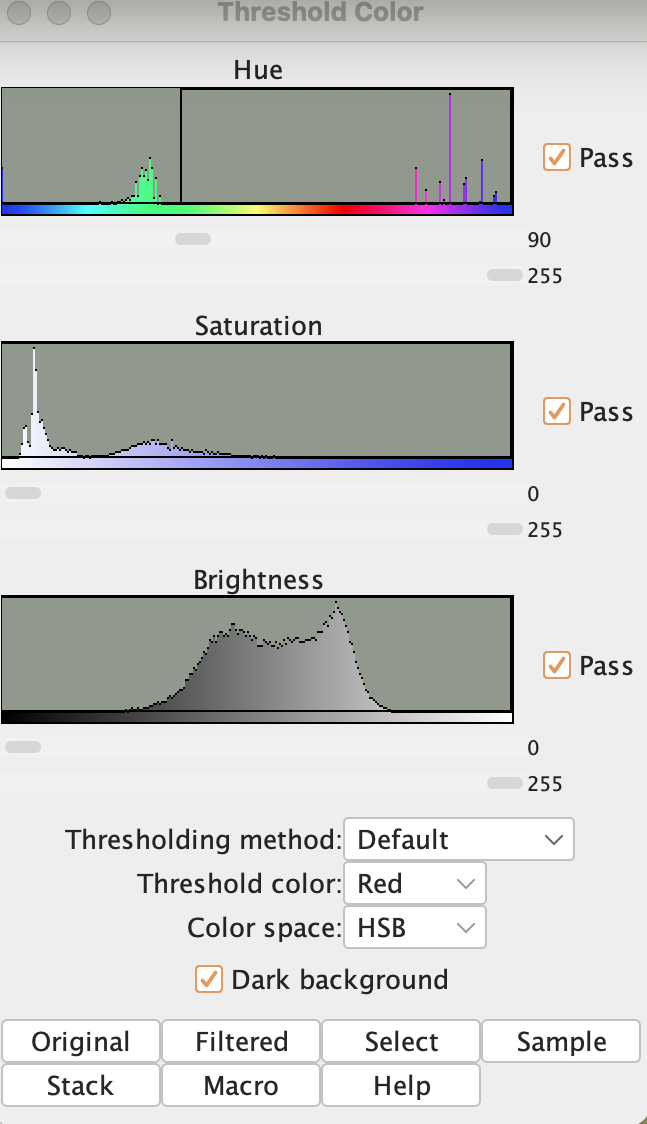

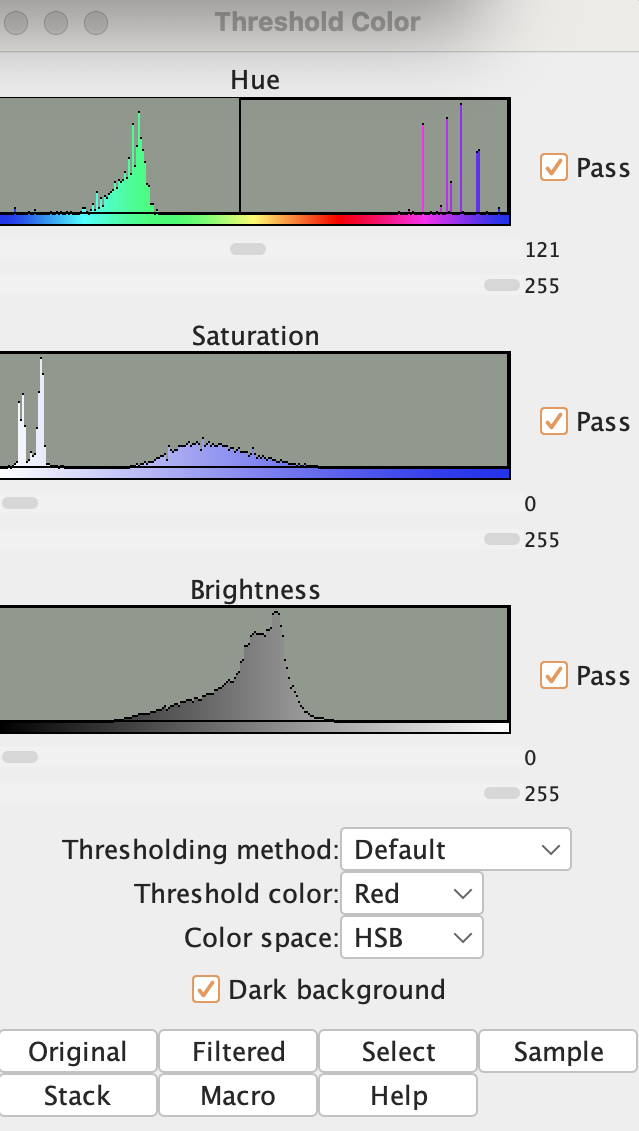

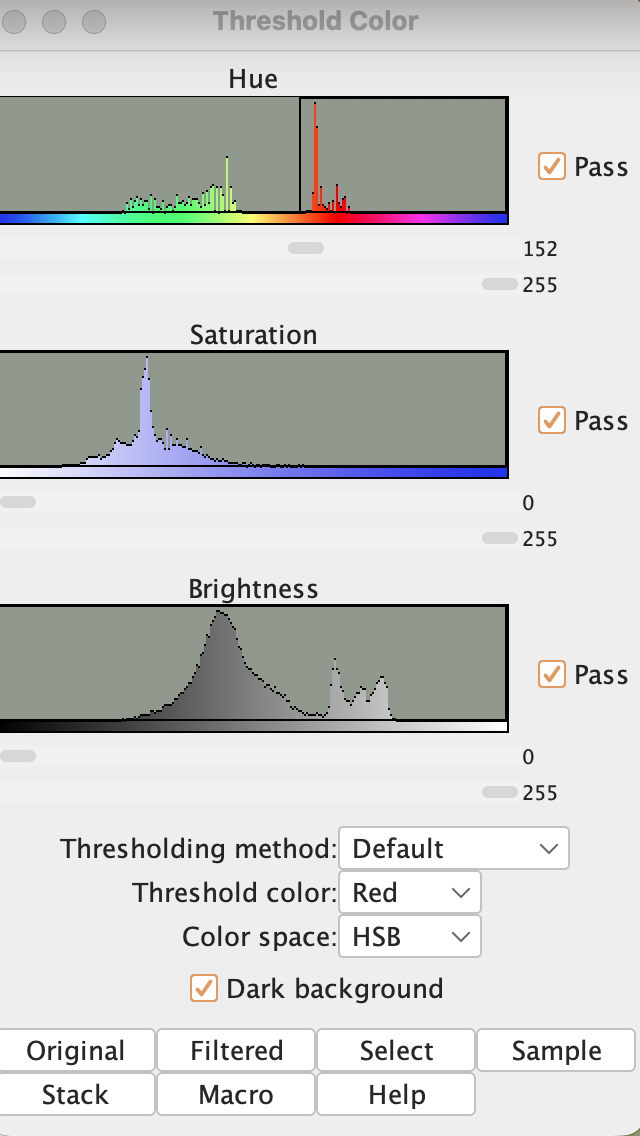

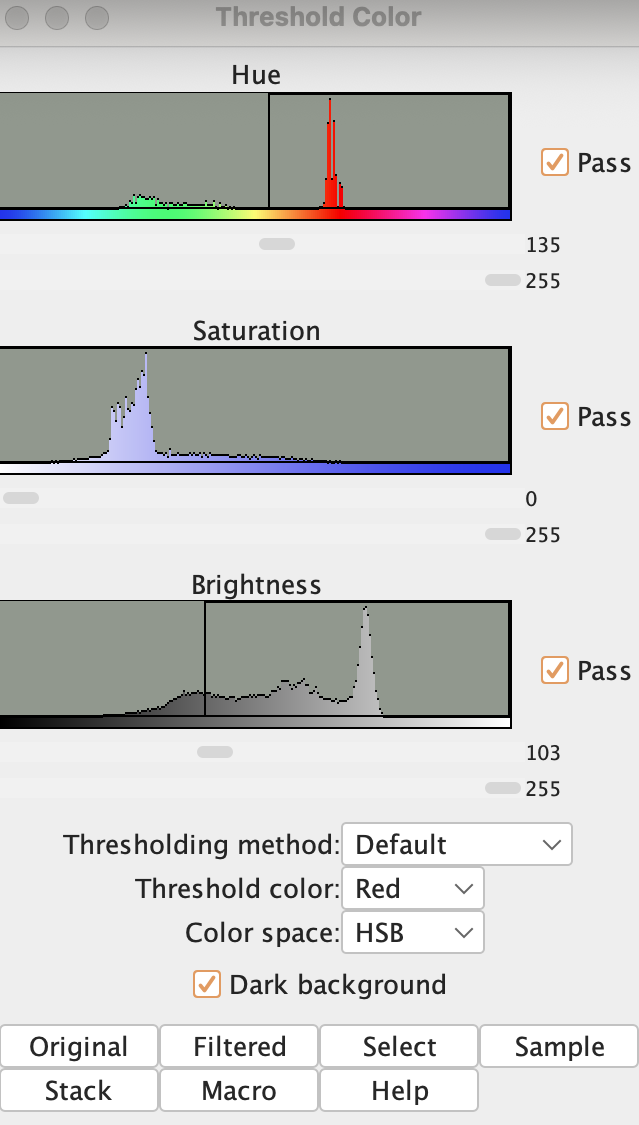

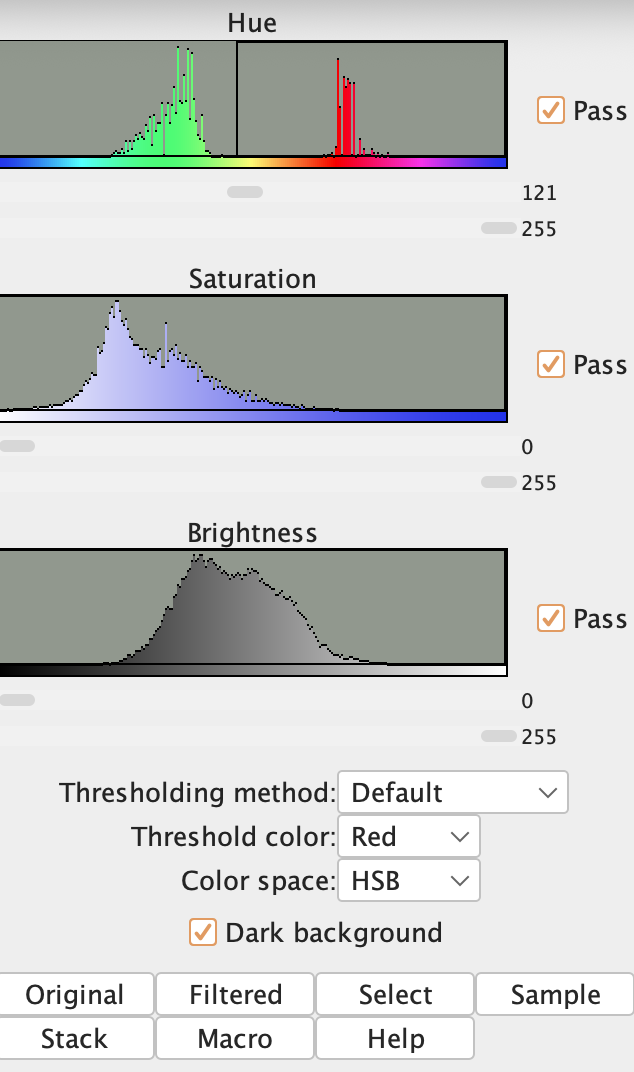

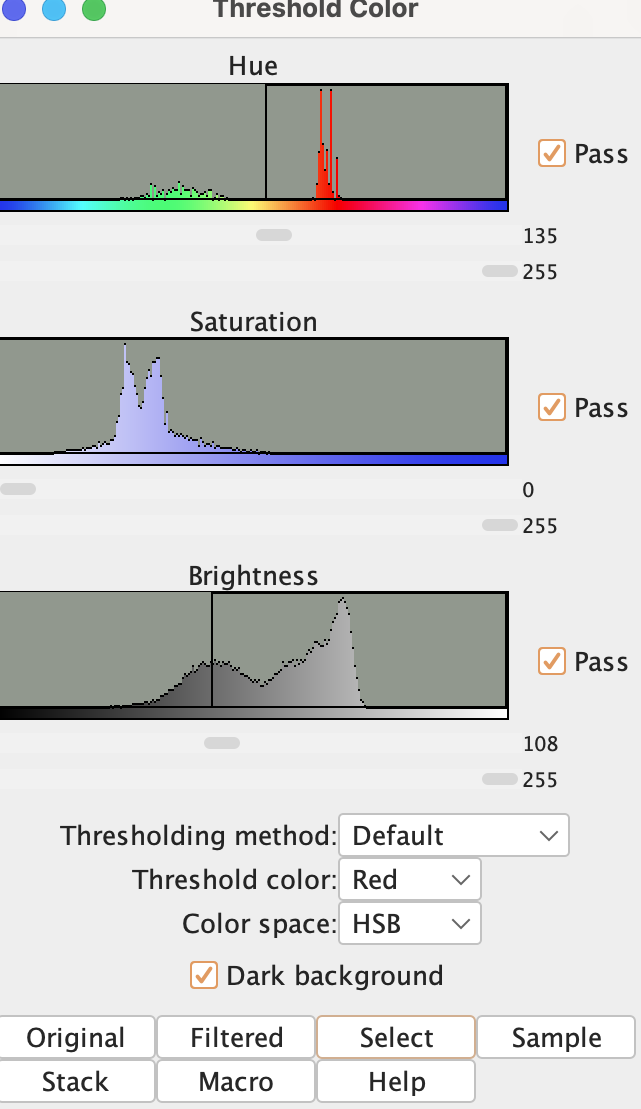

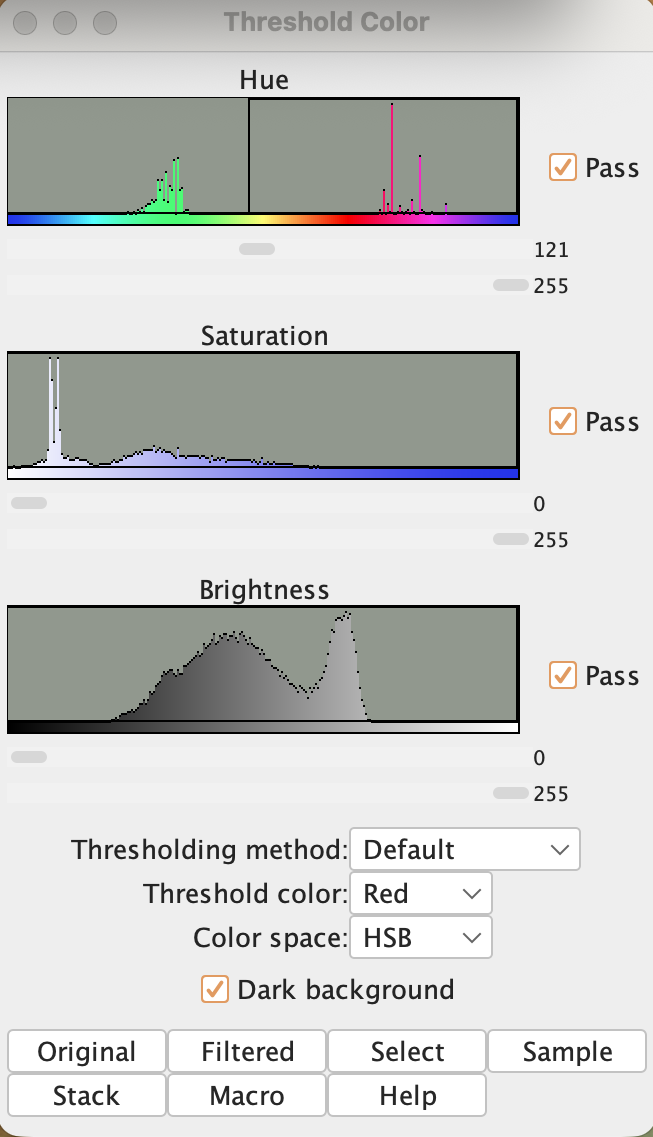

In [19]:
manual_setting = [cv.imread(os.path.join("data/setting-manual", f))
          for f in sorted(os.listdir("data/setting-manual")) if f.endswith(".png")]

for img in manual_setting:
    tools.display_image(img)

